In [1]:
import pandas as pd 
import numpy as np

df = pd.read_csv("df_LIGUE1_features.csv")

df.shape



(1738, 69)

In [2]:
df.columns.to_list()

['fixture_id',
 'season',
 'league_id',
 'date',
 'home',
 'away',
 'home_goals',
 'away_goals',
 'home_avg_rating',
 'away_avg_rating',
 'home_shots_on_goal',
 'home_shots_off_goal',
 'home_total_shots',
 'home_blocked_shots',
 'home_shots_insidebox',
 'home_shots_outsidebox',
 'home_fouls',
 'home_corner_kicks',
 'home_offsides',
 'home_ball_possession',
 'home_yellow_cards',
 'home_red_cards',
 'home_goalkeeper_saves',
 'home_total_passes',
 'home_passes_accurate',
 'home_passes_pct',
 'away_shots_on_goal',
 'away_shots_off_goal',
 'away_total_shots',
 'away_blocked_shots',
 'away_shots_insidebox',
 'away_shots_outsidebox',
 'away_fouls',
 'away_corner_kicks',
 'away_offsides',
 'away_ball_possession',
 'away_yellow_cards',
 'away_red_cards',
 'away_goalkeeper_saves',
 'away_total_passes',
 'away_passes_accurate',
 'away_passes_pct',
 'home_expected_goals',
 'away_expected_goals',
 'xg_dispo',
 'result',
 'home_form_goals_scored',
 'home_form_goals_conceded',
 'home_form_rating',
 '

In [3]:
df.head(3)

,fixture_id,season,league_id,date,home,away,home_goals,away_goals,home_avg_rating,away_avg_rating,...,away_form_points,home_win_rate,home_goals_avg,away_win_rate,away_goals_avg,h2h_home_win_rate,h2h_away_win_rate,h2h_draw_rate,h2h_home_goals,h2h_away_goals
0,571491,2020,61,2020-08-29 19:00:00+00:00,Strasbourg,Nice,0,2,6.43,7.16,...,3.0,0.406593,1.505495,0.417582,1.329670,0.300,0.300,0.400,1.400,1.200
1,571490,2020,61,2020-08-30 11:00:00+00:00,Reims,Lille,0,1,6.62,6.85,...,1.0,0.318681,1.153846,0.417582,1.362637,0.300,0.600,0.100,0.900,1.300
2,571487,2020,61,2020-08-30 13:00:00+00:00,Nantes,Nimes,2,1,6.95,6.85,...,3.0,0.293478,1.195652,0.315789,0.947368,0.333,0.333,0.333,1.222,1.333


In [4]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [5]:
# Vérifions ce que chaque valeur représente
# On prend un match où l'équipe à domicile a gagné
victoire_dom = df[df["home_goals"] > df["away_goals"]]["result"].iloc[0]

# Un match nul
nul = df[df["home_goals"] == df["away_goals"]]["result"].iloc[0]

# Une victoire extérieure
victoire_ext = df[df["home_goals"] < df["away_goals"]]["result"].iloc[0]

print(f"Victoire domicile = {victoire_dom}")
print(f"Match nul         = {nul}")
print(f"Victoire extérieur = {victoire_ext}")

Victoire domicile = 2
Match nul         = 1
Victoire extérieur = 0


In [6]:
FEATURES = [
    # Forme récente de l'équipe à domicile (5 derniers matchs)
    "home_form_goals_scored",
    "home_form_goals_conceded",
    "home_form_rating",
    "home_form_shots",
    "home_form_possession",
    "home_form_xg",
    "home_form_points",
    # Forme récente de l'équipe à l'extérieur
    "away_form_goals_scored",
    "away_form_goals_conceded",
    "away_form_rating",
    "away_form_shots",
    "away_form_possession",
    "away_form_xg",
    "away_form_points",
    # Statistiques historiques domicile/extérieur
    "home_win_rate",
    "home_goals_avg",
    "away_win_rate",
    "away_goals_avg",
    # Head-to-Head — historique des confrontations directes
    "h2h_home_win_rate",
    "h2h_away_win_rate",
    "h2h_draw_rate",
    "h2h_home_goals",
    "h2h_away_goals",
    # Contextuelles
    "xg_dispo",
    "league_id",
]

TARGET = "result"

X = df[FEATURES]

Y = df[TARGET]

X.shape[0]
X.shape[1]

Y.unique()

array([0, 2, 1])

In [7]:
distribution = Y.value_counts()
print(distribution)
print((distribution/len(Y)*100).round(1))

result
2    723
0    586
1    429
Name: count, dtype: int64
result
2    41.6
0    33.7
1    24.7
Name: count, dtype: float64


In [8]:
df = df.sort_values("date").reset_index(drop=True)

train = df[df["season"] != 2024]
test = df[df["season"] == 2024]

x_train = train[FEATURES]
y_train = train[TARGET]

x_test = test[FEATURES]
y_test = test[TARGET]

print(f"Entraînement : {len(x_train)} matchs ({train['season'].unique()})")
print(f"Test         : {len(x_test)} matchs  (saison 2024)")
print(f"\nDistribution train :\n{(y_train.value_counts()/len(y_train)*100).round(1)}")
print(f"\nDistribution test  :\n{(y_test.value_counts()/len(y_test)*100).round(1)}")


Entraînement : 1431 matchs ([2020 2021 2022 2023])
Test         : 307 matchs  (saison 2024)

Distribution train :
result
2    40.5
0    33.9
1    25.6
Name: count, dtype: float64

Distribution test  :
result
2    46.6
0    32.9
1    20.5
Name: count, dtype: float64


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Créer le modèle
# n_estimators = nombre d'arbres (100 c'est un bon point de départ)
# random_state = pour avoir des résultats reproductibles
# class_weight = "balanced" pour compenser le déséquilibre des classes (les nuls sous-représentés)
modele = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

# Entraîner le modèle sur les données d'entraînement
modele.fit(x_train, y_train)

# Faire des prédictions sur les données de test
y_pred = modele.predict(x_test)

# Évaluer l'accuracy globale
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy*100:.1f}%")
print(f"Baseline : 41.6%")
print(f"Gain vs baseline : +{(accuracy*100 - 41.6):.1f}%")
print()

# Rapport détaillé par classe
print(classification_report(y_test, y_pred, target_names=["Ext (0)", "Nul (1)", "Dom (2)"]))

Accuracy : 57.0%
Baseline : 41.6%
Gain vs baseline : +15.4%

              precision    recall  f1-score   support

     Ext (0)       0.53      0.55      0.54       101
     Nul (1)       0.39      0.25      0.31        63
     Dom (2)       0.64      0.72      0.68       143

    accuracy                           0.57       307
   macro avg       0.52      0.51      0.51       307
weighted avg       0.55      0.57      0.56       307



Precision = nuls correctement predits / total de nuls predits par le modele

Recall = nuls correctement predits​  / total de vrais nuls dans le tes

F1 = 2×( (Precision×Recall) / (Precision+Recall)  )​ = 2×((0.45×0.30​) / (0.45+0.30) ) = 2×(0.135 / 0.750) ​= 0.36


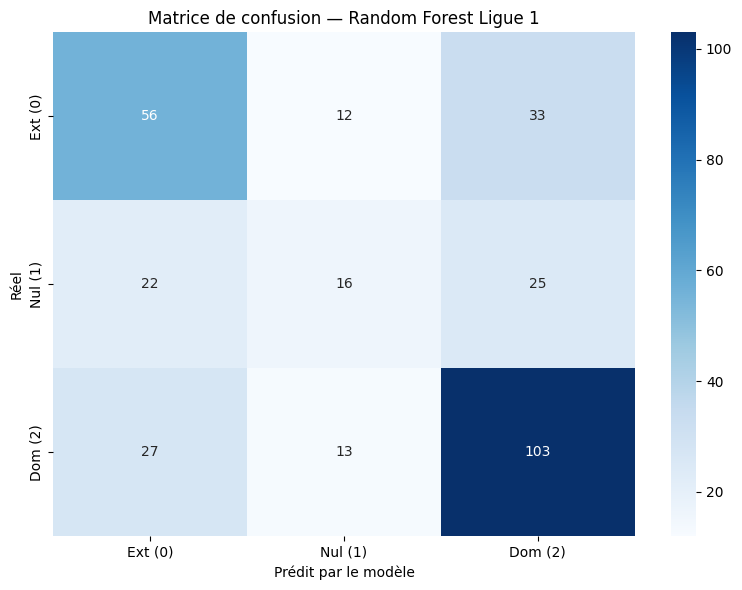

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculer la matrice de confusion
cm = confusion_matrix(y_test, y_pred)

# Visualiser avec une heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,           # affiche les chiffres dans chaque case
    fmt="d",              # format entier
    cmap="Blues",         # couleur bleue — plus foncé = plus de cas
    xticklabels=["Ext (0)", "Nul (1)", "Dom (2)"],
    yticklabels=["Ext (0)", "Nul (1)", "Dom (2)"]
)
plt.xlabel("Prédit par le modèle")
plt.ylabel("Réel")
plt.title("Matrice de confusion — Random Forest Ligue 1")
plt.tight_layout()
plt.show()

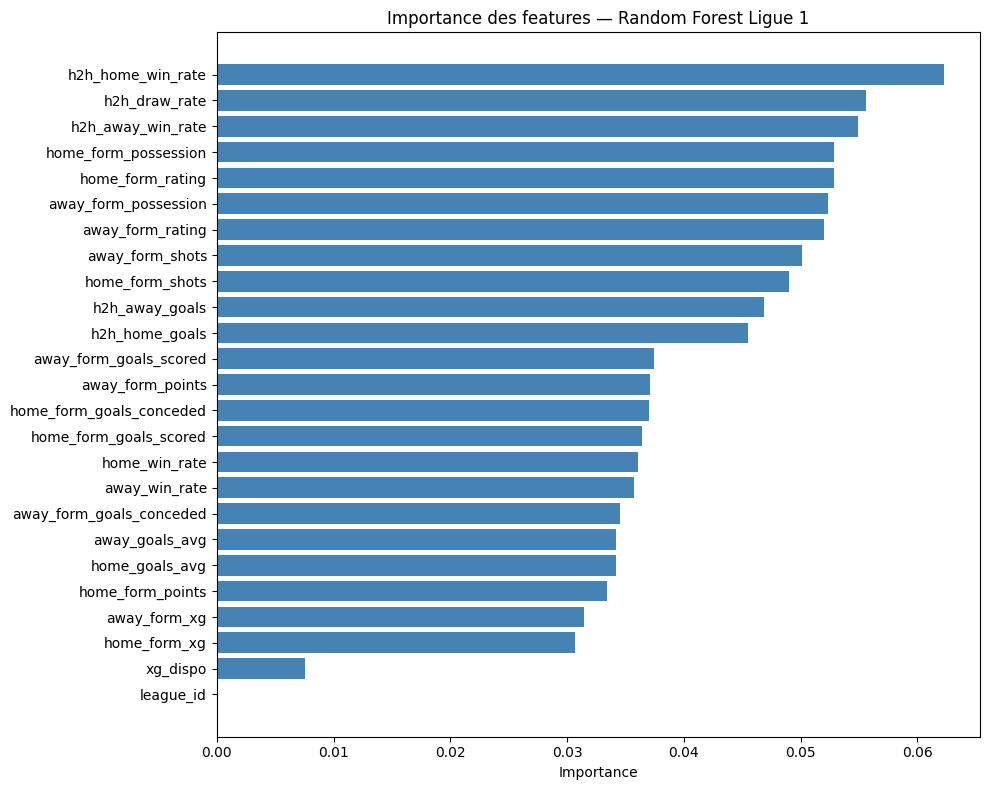

                 feature  importance
       h2h_home_win_rate    0.062242
           h2h_draw_rate    0.055565
       h2h_away_win_rate    0.054918
    home_form_possession    0.052872
        home_form_rating    0.052870
    away_form_possession    0.052322
        away_form_rating    0.051978
         away_form_shots    0.050095
         home_form_shots    0.049031
          h2h_away_goals    0.046878
          h2h_home_goals    0.045450
  away_form_goals_scored    0.037482
        away_form_points    0.037086
home_form_goals_conceded    0.037017
  home_form_goals_scored    0.036399
           home_win_rate    0.036052
           away_win_rate    0.035753
away_form_goals_conceded    0.034492
          away_goals_avg    0.034158
          home_goals_avg    0.034148
        home_form_points    0.033431
            away_form_xg    0.031487
            home_form_xg    0.030708
                xg_dispo    0.007567
               league_id    0.000000


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Récupérer l'importance de chaque feature selon le Random Forest
# Le modèle calcule ça automatiquement pendant l'entraînement
importances = modele.feature_importances_

# Créer un dataframe pour mieux visualiser
df_importance = pd.DataFrame({
    "feature":    FEATURES,
    "importance": importances
}).sort_values("importance", ascending=False)

# Visualiser avec un graphique à barres horizontales
plt.figure(figsize=(10, 8))
plt.barh(df_importance["feature"], df_importance["importance"], color="steelblue")
plt.xlabel("Importance")
plt.title("Importance des features — Random Forest Ligue 1")
plt.gca().invert_yaxis()  # la plus importante en haut
plt.tight_layout()
plt.show()

# Afficher aussi les chiffres
print(df_importance.to_string(index=False))

In [12]:
from sklearn.model_selection import GridSearchCV

# La grille des hyperparamètres à tester
# GridSearch va tester toutes les combinaisons possibles
# ici : 3 × 3 × 3 = 27 combinaisons × 3 folds = 81 entraînements
param_grid = {
    "n_estimators": [100, 200, 300],      # nombre d'arbres
    "max_depth":    [5, 10, None],         # profondeur max (None = pas de limite)
    "min_samples_split": [2, 5, 10],       # min exemples pour diviser un noeud
}

# GridSearchCV — le CV signifie Cross Validation
# cv=3 → il divise le train en 3 parties et teste sur chacune
# scoring="accuracy" → il optimise sur l'accuracy
# n_jobs=-1 → utilise tous les cœurs de ton CPU pour aller plus vite
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1   # affiche la progression
)

# Lancer la recherche sur les données d'entraînement
grid_search.fit(x_train, y_train)

# Afficher les meilleurs hyperparamètres trouvés
print(f"Meilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Meilleure accuracy en validation : {grid_search.best_score_*100:.1f}%")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Meilleurs hyperparamètres : {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Meilleure accuracy en validation : 53.5%


In [13]:
# Récupérer le meilleur modèle trouvé par GridSearch
meilleur_modele = grid_search.best_estimator_

# Faire des prédictions sur le test set (saison 2024)
y_pred_optimise = meilleur_modele.predict(x_test)

# Comparer avec le modèle de base
accuracy_optimise = accuracy_score(y_test, y_pred_optimise)
print(f"Accuracy modèle de base    : 58.0%")
print(f"Accuracy modèle optimisé   : {accuracy_optimise*100:.1f}%")
print()
print(classification_report(y_test, y_pred_optimise,
      target_names=["Ext (0)", "Nul (1)", "Dom (2)"]))

Accuracy modèle de base    : 58.0%
Accuracy modèle optimisé   : 58.0%

              precision    recall  f1-score   support

     Ext (0)       0.55      0.64      0.59       101
     Nul (1)       0.40      0.43      0.41        63
     Dom (2)       0.71      0.60      0.65       143

    accuracy                           0.58       307
   macro avg       0.55      0.56      0.55       307
weighted avg       0.59      0.58      0.58       307

